# CSE440 Final Project 

## 1) Imports and Setup

In [1]:
# If needed, uncomment to install dependencies
# !pip install -q pandas numpy scikit-learn matplotlib seaborn nltk gensim wordcloud tensorflow

import re
import html
import random
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

from gensim.models import Word2Vec

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Embedding, SimpleRNN, GRU, LSTM, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

for pkg in ['punkt', 'punkt_tab', 'stopwords', 'wordnet', 'omw-1.4']:
    try:
        nltk.download(pkg, quiet=True)
    except Exception as exc:
        print('nltk.download skipped or failed:', pkg, exc)

# After normalize_text(), tokens are letters-only words; split() avoids Punkt LookupError on some setups.

## 2) Load Dataset

In [3]:
TRAIN_PATH = 'Training_data_9.csv'
TEST_PATH = 'Test_data.csv'

train_df = pd.read_csv("I:/CSE440-Project/Training_data_9.csv")
test_df = pd.read_csv("I:/CSE440-Project/Test_data.csv")

train_df = train_df.rename(columns={'News Headline': 'text', 'News Topic': 'label'})
test_df = test_df.rename(columns={'News Headline': 'text', 'News Topic': 'label'})

print('Train shape:', train_df.shape)
print('Test shape:', test_df.shape)
print('\nLabel distribution in train:')
print(train_df['label'].value_counts())

train_df.head()

Train shape: (88829, 2)
Test shape: (12000, 2)

Label distribution in train:
label
Sports                    35668
World News                31613
Business                  11801
Science and Technology     9747
Name: count, dtype: int64


,text,label
0,<html> <body> News Headlines:\n <br> <b> Jacks...,Sports
1,<html> <body> News Headlines:\n <br> <b> Howar...,World News
2,<html> <body> News Headlines:\n <br> <b> WinXP...,Science and Technology
3,<html> <body> News Headlines:\n <br> <b> Chief...,Sports
4,<html> <body> News Headlines:\n <br> <b> Poll ...,World News


## 3) EDA (Lab1 style)

,clean_eda,label,char_len,word_len
0,News Headlines: Jackson second to Leslie for M...,Sports,253,45
1,News Headlines: Howard plans regional spy scho...,World News,181,28
2,News Headlines: WinXP SP2 Home Edition To Be A...,Science and Technology,255,42


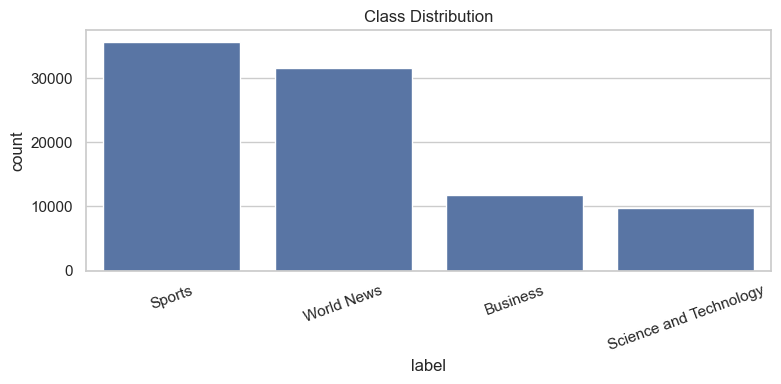

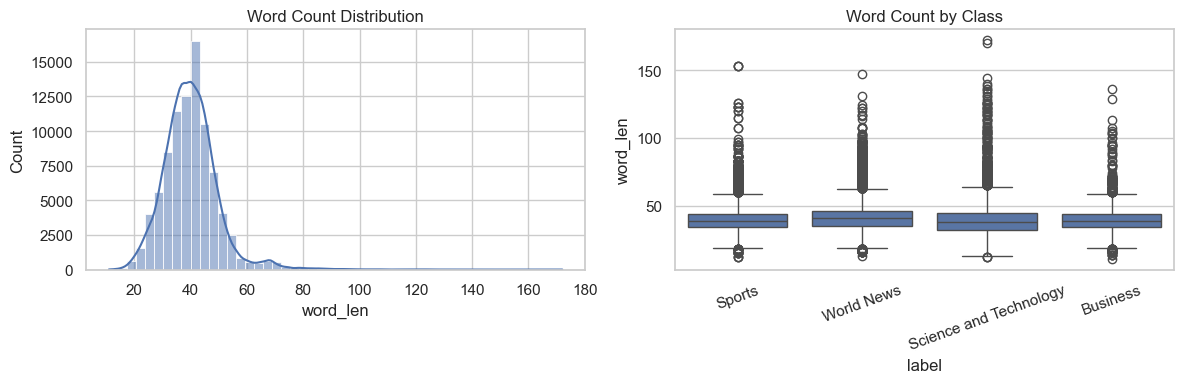

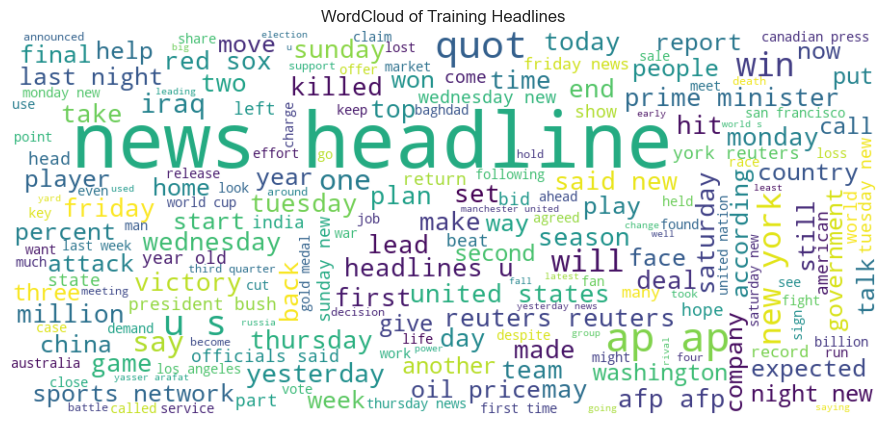

,token,count
0,the,158735
1,news,90486
2,headlines:,88831
3,to,86599
4,a,81468
5,in,76294
6,of,71717
7,and,49720
8,on,41689
9,for,37149


In [4]:
def strip_html_noise(text):
    text = str(text)
    text = html.unescape(text)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

eda_df = train_df.copy()
eda_df['clean_eda'] = eda_df['text'].apply(strip_html_noise)
eda_df['char_len'] = eda_df['clean_eda'].str.len()
eda_df['word_len'] = eda_df['clean_eda'].str.split().str.len()

display(eda_df[['clean_eda', 'label', 'char_len', 'word_len']].head(3))

plt.figure(figsize=(8, 4))
sns.countplot(data=eda_df, x='label', order=eda_df['label'].value_counts().index)
plt.title('Class Distribution')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(eda_df['word_len'], bins=50, kde=True, ax=ax[0])
ax[0].set_title('Word Count Distribution')
sns.boxplot(data=eda_df, x='label', y='word_len', ax=ax[1])
ax[1].set_title('Word Count by Class')
ax[1].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

all_text = ' '.join(eda_df['clean_eda']).lower()
wc = WordCloud(width=900, height=400, background_color='white').generate(all_text)
plt.figure(figsize=(14, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud of Training Headlines')
plt.show()

top_tokens = Counter(all_text.split()).most_common(30)
pd.DataFrame(top_tokens, columns=['token', 'count'])

## 4) Build Three Preprocessing Variants

- **No preprocessing**: raw headlines
- **Extreme preprocessing**: HTML removal, lowercase, punctuation removal, stopwords removal, lemmatization, stemming
- **Optimum preprocessing**: moderate cleaning based on EDA, keeps negation terms for sentiment/context preservation

In [5]:
STOPWORDS = set(stopwords.words('english'))
NEGATION_KEEP = {'no', 'not', 'nor'}
STOPWORDS_OPTIMUM = STOPWORDS - NEGATION_KEEP
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def preprocess_none(text):
    return str(text)

def normalize_text(text):
    text = str(text)
    text = html.unescape(text)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip().lower()
    return text

def preprocess_extreme(text):
    text = normalize_text(text)
    tokens = text.split()
    tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 1]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    tokens = [stemmer.stem(t) for t in tokens]
    return ' '.join(tokens)

def preprocess_optimum(text):
    text = normalize_text(text)
    tokens = text.split()
    tokens = [t for t in tokens if t not in STOPWORDS_OPTIMUM and len(t) > 1]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

PREPROCESSORS = {
    'none': preprocess_none,
    'extreme': preprocess_extreme,
    'optimum': preprocess_optimum
}

## 5) Split Data + Encode Labels

In [6]:
# Set FAST_MODE=True for debugging only, False for final report runs
FAST_MODE = False
FAST_SAMPLES_PER_CLASS = 2500

work_train = train_df.copy()
work_test = test_df.copy()

if FAST_MODE:
    work_train = work_train.groupby('label', group_keys=False).apply(lambda x: x.sample(min(len(x), FAST_SAMPLES_PER_CLASS), random_state=SEED)).reset_index(drop=True)
    work_test = work_test.groupby('label', group_keys=False).apply(lambda x: x.sample(min(len(x), max(700, FAST_SAMPLES_PER_CLASS // 2)), random_state=SEED)).reset_index(drop=True)

train_part, val_part = train_test_split(
    work_train,
    test_size=0.15,
    random_state=SEED,
    stratify=work_train['label']
)

label_encoder = LabelEncoder()
label_encoder.fit(work_train['label'])

y_train = label_encoder.transform(train_part['label'])
y_val = label_encoder.transform(val_part['label'])
y_test = label_encoder.transform(work_test['label'])

num_classes = len(label_encoder.classes_)

y_train_oh = to_categorical(y_train, num_classes=num_classes)
y_val_oh = to_categorical(y_val, num_classes=num_classes)
y_test_oh = to_categorical(y_test, num_classes=num_classes)

print('Train split:', train_part.shape)
print('Val split:', val_part.shape)
print('Test split:', work_test.shape)
print('Classes:', list(label_encoder.classes_))

Train split: (75504, 2)
Val split: (13325, 2)
Test split: (12000, 2)
Classes: ['Business', 'Science and Technology', 'Sports', 'World News']


## 6) Shared Utility Functions

In [7]:
all_results = []
tuning_logs = []

def get_preprocessed_splits(prep_fn):
    X_train_text = train_part['text'].apply(prep_fn).astype(str).values
    X_val_text = val_part['text'].apply(prep_fn).astype(str).values
    X_test_text = work_test['text'].apply(prep_fn).astype(str).values
    return X_train_text, X_val_text, X_test_text

def evaluate_and_store(y_true, y_pred, prep_name, rep_name, model_name):
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    cm = confusion_matrix(y_true, y_pred)

    print(f'\n[{prep_name} | {rep_name} | {model_name}]')
    print(f'Accuracy: {acc:.4f}')
    print(f'Macro F1: {macro_f1:.4f}')
    print('Classification report:')
    print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
    plt.title(f'Confusion Matrix - {prep_name} | {rep_name} | {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.xticks(rotation=20)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    all_results.append({
        'preprocessing': prep_name,
        'representation': rep_name,
        'model': model_name,
        'accuracy': acc,
        'macro_f1': macro_f1
    })

def add_tuning_log(prep, rep, model, config, val_f1):
    tuning_logs.append({
        'preprocessing': prep,
        'representation': rep,
        'model': model,
        'config': str(config),
        'val_macro_f1': float(val_f1)
    })

## 7) TF-IDF + Logistic Regression (ML) + Deep NN (Keras)


TF-IDF experiments for preprocessing: none
LR cfg: {'max_features': 5000, 'min_df': 2, 'ngram_range': (1, 1)} + {'C': 0.5, 'max_iter': 400, 'solver': 'lbfgs'} -> val_macro_f1=0.8954
LR cfg: {'max_features': 5000, 'min_df': 2, 'ngram_range': (1, 1)} + {'C': 1.0, 'max_iter': 400, 'solver': 'lbfgs'} -> val_macro_f1=0.8990
LR cfg: {'max_features': 5000, 'min_df': 2, 'ngram_range': (1, 1)} + {'C': 2.0, 'max_iter': 400, 'solver': 'lbfgs'} -> val_macro_f1=0.9008
LR cfg: {'max_features': 5000, 'min_df': 2, 'ngram_range': (1, 2)} + {'C': 0.5, 'max_iter': 400, 'solver': 'lbfgs'} -> val_macro_f1=0.8852
LR cfg: {'max_features': 5000, 'min_df': 2, 'ngram_range': (1, 2)} + {'C': 1.0, 'max_iter': 400, 'solver': 'lbfgs'} -> val_macro_f1=0.8906
LR cfg: {'max_features': 5000, 'min_df': 2, 'ngram_range': (1, 2)} + {'C': 2.0, 'max_iter': 400, 'solver': 'lbfgs'} -> val_macro_f1=0.8915
LR cfg: {'max_features': 8000, 'min_df': 2, 'ngram_range': (1, 1)} + {'C': 0.5, 'max_iter': 400, 'solver': 'lbfgs'} -> val

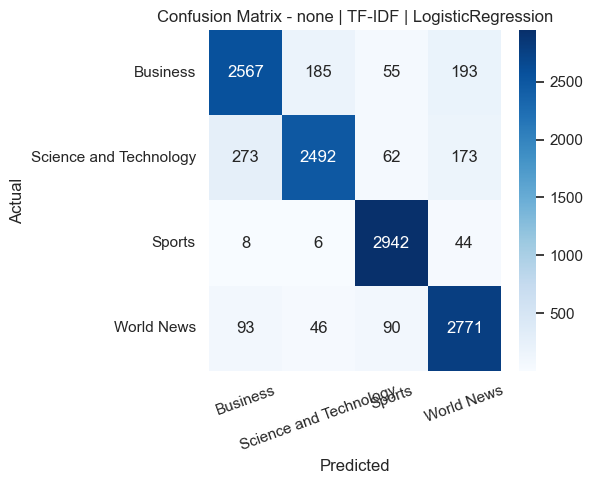

Epoch 1/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.9008 - loss: 0.2840 - val_accuracy: 0.9394 - val_loss: 0.1836
Epoch 2/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.9576 - loss: 0.1279 - val_accuracy: 0.9445 - val_loss: 0.1760
Epoch 3/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.9757 - loss: 0.0730 - val_accuracy: 0.9475 - val_loss: 0.1978
Epoch 4/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.9860 - loss: 0.0419 - val_accuracy: 0.9481 - val_loss: 0.2359
DeepNN cfg: {'batch_size': 64, 'dense1': 256, 'dense2': 128, 'drop': 0.35, 'epochs': 50, 'lr': 0.001} -> val_macro_f1=0.9162
Epoch 1/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.8941 - loss: 0.3040 - val_accuracy: 0.9381 - val_loss: 0.1878
Epoch 2/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.9523 - loss: 0.1462 - val_accuracy: 0.9446 - val_loss: 0.1736
Epoch 3/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.9695 - loss: 0.0

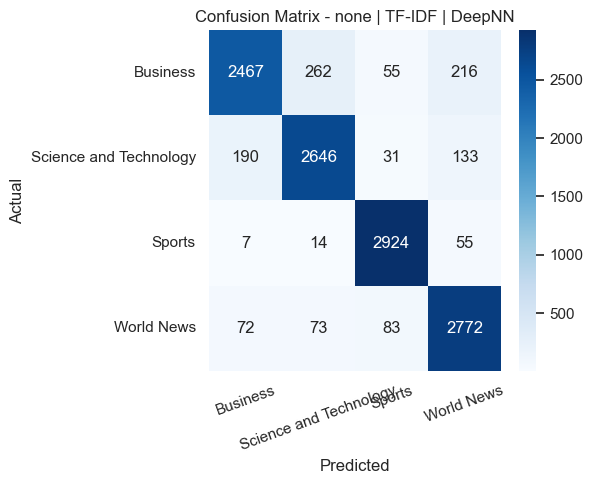


TF-IDF experiments for preprocessing: extreme
LR cfg: {'max_features': 5000, 'min_df': 2, 'ngram_range': (1, 1)} + {'C': 0.5, 'max_iter': 400, 'solver': 'lbfgs'} -> val_macro_f1=0.8981
LR cfg: {'max_features': 5000, 'min_df': 2, 'ngram_range': (1, 1)} + {'C': 1.0, 'max_iter': 400, 'solver': 'lbfgs'} -> val_macro_f1=0.9013
LR cfg: {'max_features': 5000, 'min_df': 2, 'ngram_range': (1, 1)} + {'C': 2.0, 'max_iter': 400, 'solver': 'lbfgs'} -> val_macro_f1=0.9032
LR cfg: {'max_features': 5000, 'min_df': 2, 'ngram_range': (1, 2)} + {'C': 0.5, 'max_iter': 400, 'solver': 'lbfgs'} -> val_macro_f1=0.8963
LR cfg: {'max_features': 5000, 'min_df': 2, 'ngram_range': (1, 2)} + {'C': 1.0, 'max_iter': 400, 'solver': 'lbfgs'} -> val_macro_f1=0.9016
LR cfg: {'max_features': 5000, 'min_df': 2, 'ngram_range': (1, 2)} + {'C': 2.0, 'max_iter': 400, 'solver': 'lbfgs'} -> val_macro_f1=0.9026
LR cfg: {'max_features': 8000, 'min_df': 2, 'ngram_range': (1, 1)} + {'C': 0.5, 'max_iter': 400, 'solver': 'lbfgs'} -> 

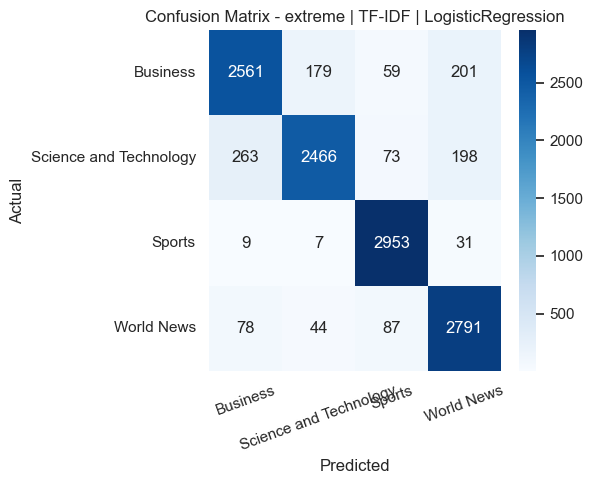

Epoch 1/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.9005 - loss: 0.2823 - val_accuracy: 0.9375 - val_loss: 0.1838
Epoch 2/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.9546 - loss: 0.1334 - val_accuracy: 0.9442 - val_loss: 0.1803
Epoch 3/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.9722 - loss: 0.0822 - val_accuracy: 0.9451 - val_loss: 0.1970
Epoch 4/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.9832 - loss: 0.0494 - val_accuracy: 0.9479 - val_loss: 0.2365
DeepNN cfg: {'batch_size': 64, 'dense1': 256, 'dense2': 128, 'drop': 0.35, 'epochs': 50, 'lr': 0.001} -> val_macro_f1=0.9150
Epoch 1/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.8929 - loss: 0.3025 - val_accuracy: 0.9371 - val_loss: 0.1856
Epoch 2/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.9500 - loss: 0.1496 - val_accuracy: 0.9431 - val_loss: 0.1812
DeepNN cfg: {'batch_size': 64, 'dense1': 256, 'dense2': 128, 'drop': 0.5, 'epochs': 

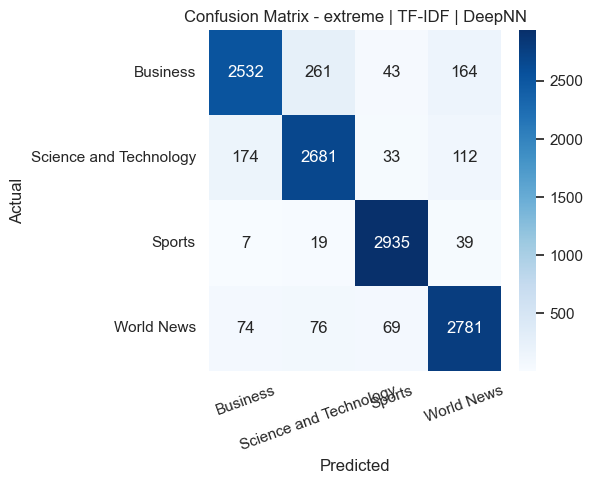


TF-IDF experiments for preprocessing: optimum
LR cfg: {'max_features': 5000, 'min_df': 2, 'ngram_range': (1, 1)} + {'C': 0.5, 'max_iter': 400, 'solver': 'lbfgs'} -> val_macro_f1=0.8973
LR cfg: {'max_features': 5000, 'min_df': 2, 'ngram_range': (1, 1)} + {'C': 1.0, 'max_iter': 400, 'solver': 'lbfgs'} -> val_macro_f1=0.8997
LR cfg: {'max_features': 5000, 'min_df': 2, 'ngram_range': (1, 1)} + {'C': 2.0, 'max_iter': 400, 'solver': 'lbfgs'} -> val_macro_f1=0.9015
LR cfg: {'max_features': 5000, 'min_df': 2, 'ngram_range': (1, 2)} + {'C': 0.5, 'max_iter': 400, 'solver': 'lbfgs'} -> val_macro_f1=0.8942
LR cfg: {'max_features': 5000, 'min_df': 2, 'ngram_range': (1, 2)} + {'C': 1.0, 'max_iter': 400, 'solver': 'lbfgs'} -> val_macro_f1=0.9006
LR cfg: {'max_features': 5000, 'min_df': 2, 'ngram_range': (1, 2)} + {'C': 2.0, 'max_iter': 400, 'solver': 'lbfgs'} -> val_macro_f1=0.9008
LR cfg: {'max_features': 8000, 'min_df': 2, 'ngram_range': (1, 1)} + {'C': 0.5, 'max_iter': 400, 'solver': 'lbfgs'} -> 

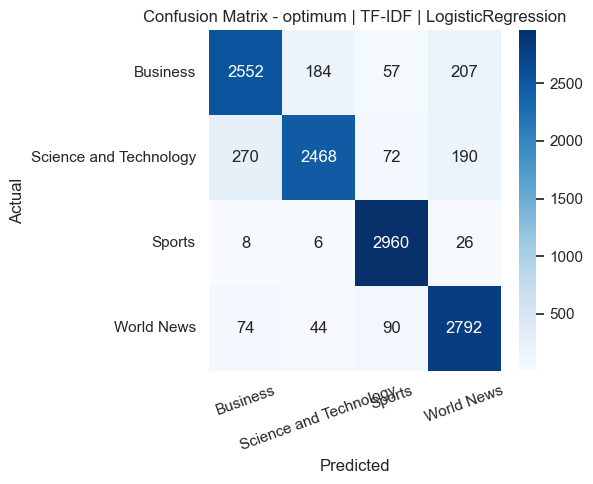

Epoch 1/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.9030 - loss: 0.2782 - val_accuracy: 0.9382 - val_loss: 0.1856
Epoch 2/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.9569 - loss: 0.1304 - val_accuracy: 0.9441 - val_loss: 0.1760
Epoch 3/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.9737 - loss: 0.0781 - val_accuracy: 0.9472 - val_loss: 0.1936
Epoch 4/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.9840 - loss: 0.0472 - val_accuracy: 0.9478 - val_loss: 0.2278
DeepNN cfg: {'batch_size': 64, 'dense1': 256, 'dense2': 128, 'drop': 0.35, 'epochs': 50, 'lr': 0.001} -> val_macro_f1=0.9139
Epoch 1/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.8942 - loss: 0.3027 - val_accuracy: 0.9408 - val_loss: 0.1839
Epoch 2/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.9513 - loss: 0.1505 - val_accuracy: 0.9446 - val_loss: 0.1719
Epoch 3/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.9658 - loss: 0.10

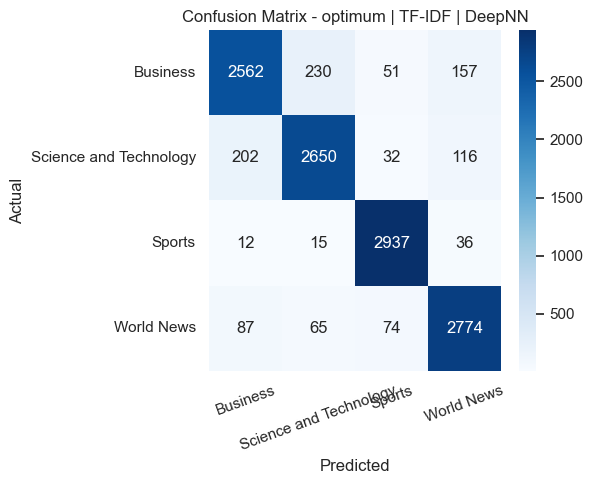

In [10]:
def build_tfidf_dnn(input_dim, num_classes, dense1=256, dense2=128, drop=0.5, lr=1e-3):
    model = Sequential([
        Dense(dense1, activation='relu', input_shape=(input_dim,)),
        Dropout(drop),
        Dense(dense2, activation='relu'),
        Dropout(drop),
        Dense(64, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

tfidf_grid = {
    'max_features': [5000, 8000],
    'ngram_range': [(1, 1), (1, 2)],
    'min_df': [2]
}

lr_grid = {
    'C': [0.5, 1.0, 2.0],
    'solver': ['lbfgs'],
    'max_iter': [400]
}

dnn_grid = {
    'dense1': [256, 384],
    'dense2': [128, 192],
    'drop': [0.35, 0.5],
    'lr': [1e-3],
    'batch_size': [64],
    'epochs': [50]
}

for prep_name, prep_fn in PREPROCESSORS.items():
    print('\n' + '=' * 95)
    print('TF-IDF experiments for preprocessing:', prep_name)

    X_train_text, X_val_text, X_test_text = get_preprocessed_splits(prep_fn)

    best_lr_f1 = -1
    best_lr_model = None
    best_vectorizer = None

    for tfcfg in ParameterGrid(tfidf_grid):
        vectorizer = TfidfVectorizer(**tfcfg)
        X_tr = vectorizer.fit_transform(X_train_text)
        X_va = vectorizer.transform(X_val_text)

        for lrcfg in ParameterGrid(lr_grid):
            lr_model = LogisticRegression(random_state=SEED, **lrcfg)
            lr_model.fit(X_tr, y_train)
            val_pred = lr_model.predict(X_va)
            val_f1 = f1_score(y_val, val_pred, average='macro')
            add_tuning_log(prep_name, 'TF-IDF', 'LogisticRegression', {**tfcfg, **lrcfg}, val_f1)
            print(f'LR cfg: {tfcfg} + {lrcfg} -> val_macro_f1={val_f1:.4f}')
            if val_f1 > best_lr_f1:
                best_lr_f1 = val_f1
                best_lr_model = lr_model
                best_vectorizer = vectorizer

    X_te = best_vectorizer.transform(X_test_text)
    test_pred_lr = best_lr_model.predict(X_te)
    evaluate_and_store(y_test, test_pred_lr, prep_name, 'TF-IDF', 'LogisticRegression')

    X_tr_dense = best_vectorizer.fit_transform(X_train_text).toarray().astype(np.float32)
    X_va_dense = best_vectorizer.transform(X_val_text).toarray().astype(np.float32)
    X_te_dense = best_vectorizer.transform(X_test_text).toarray().astype(np.float32)

    best_dnn_f1 = -1
    best_dnn_model = None
    early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

    for dcfg in ParameterGrid(dnn_grid):
        dnn = build_tfidf_dnn(
            input_dim=X_tr_dense.shape[1],
            num_classes=num_classes,
            dense1=dcfg['dense1'],
            dense2=dcfg['dense2'],
            drop=dcfg['drop'],
            lr=dcfg['lr']
        )
        dnn.fit(
            X_tr_dense, y_train_oh,
            validation_data=(X_va_dense, y_val_oh),
            epochs=dcfg['epochs'],
            batch_size=dcfg['batch_size'],
            verbose=1,
            callbacks=[early_stop]
        )
        val_pred = np.argmax(dnn.predict(X_va_dense, verbose=0), axis=1)
        val_f1 = f1_score(y_val, val_pred, average='macro')
        add_tuning_log(prep_name, 'TF-IDF', 'DeepNN', dcfg, val_f1)
        print(f'DeepNN cfg: {dcfg} -> val_macro_f1={val_f1:.4f}')
        if val_f1 > best_dnn_f1:
            best_dnn_f1 = val_f1
            best_dnn_model = dnn

    test_pred_dnn = np.argmax(best_dnn_model.predict(X_te_dense, verbose=0), axis=1)
    evaluate_and_store(y_test, test_pred_dnn, prep_name, 'TF-IDF', 'DeepNN')

## 8) Skip-gram + All Required Sequence Models


Skip-gram experiments for preprocessing: none
Epoch 1/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.4994 - loss: 1.1533 - val_accuracy: 0.3980 - val_loss: 1.2521
Epoch 2/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.3967 - loss: 1.2483 - val_accuracy: 0.4068 - val_loss: 1.2459
Epoch 3/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4322 - loss: 1.2131 - val_accuracy: 0.5008 - val_loss: 1.4538
Epoch 4/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5069 - loss: 1.1584 - val_accuracy: 0.4111 - val_loss: 1.2424
Epoch 5/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4048 - loss: 1.2431 - val_accuracy: 0.4022 - val_loss: 1.2474
Epoch 6/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4035 - loss: 1.2472 - val_accuracy: 0.4020 - val_loss: 1.2478
SimpleRNN cfg: {'batch_size': 64, 'dropout_rate': 0.4, 'epochs': 50, 'lr': 0.001, 'units': 64} -> val_macro_f1=0.1633
Epoch 1/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step -

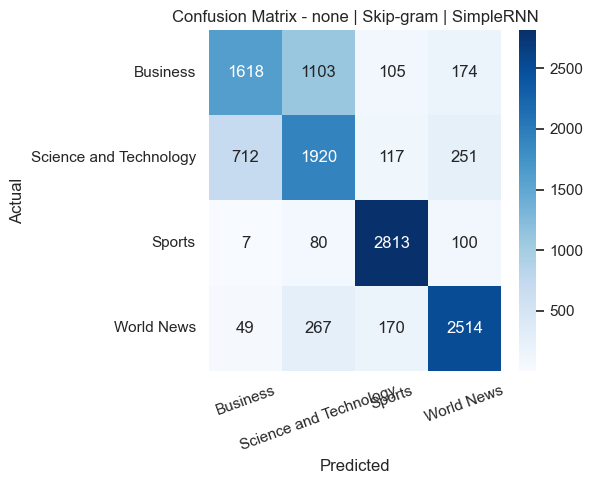

Epoch 1/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.8069 - loss: 0.4906 - val_accuracy: 0.8937 - val_loss: 0.3112
Epoch 2/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.9072 - loss: 0.2751 - val_accuracy: 0.9069 - val_loss: 0.2603
Epoch 3/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.9200 - loss: 0.2376 - val_accuracy: 0.9167 - val_loss: 0.2388
Epoch 4/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.9285 - loss: 0.2110 - val_accuracy: 0.9248 - val_loss: 0.2199
Epoch 5/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - accuracy: 0.9348 - loss: 0.1913 - val_accuracy: 0.9277 - val_loss: 0.2143
Epoch 6/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - accuracy: 0.9404 - loss: 0.1753 - val_accuracy: 0.9271 - val_loss: 0.2192
Epoch 7/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.9451 - loss: 0.1606 - val_accuracy: 0.9216 - val_loss: 0.2343
GRU cfg: {'batch_size': 64, 'dropout_rate': 0.4, 'epochs': 50, 'lr': 0.001, 

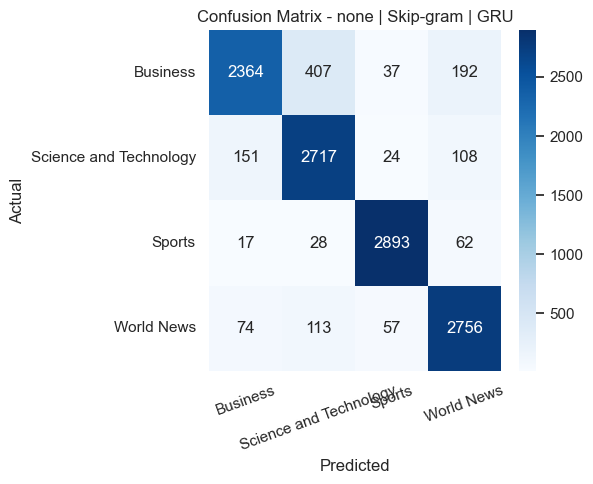

Epoch 1/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.8472 - loss: 0.4400 - val_accuracy: 0.8786 - val_loss: 0.3457
Epoch 2/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.8966 - loss: 0.3125 - val_accuracy: 0.8956 - val_loss: 0.3003
Epoch 3/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.9098 - loss: 0.2707 - val_accuracy: 0.9108 - val_loss: 0.2566
Epoch 4/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.9199 - loss: 0.2417 - val_accuracy: 0.9146 - val_loss: 0.2552
Epoch 5/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.9268 - loss: 0.2176 - val_accuracy: 0.9226 - val_loss: 0.2312
Epoch 6/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.9317 - loss: 0.2009 - val_accuracy: 0.9168 - val_loss: 0.2371
Epoch 7/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.9377 - loss: 0.1829 - val_accuracy: 0.9280 - val_loss: 0.2143
Epoch 8/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.9427 -

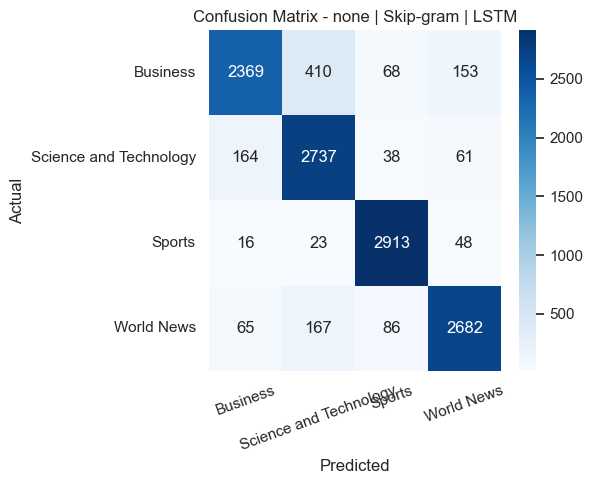

Epoch 1/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7403 - loss: 0.7031 - val_accuracy: 0.8295 - val_loss: 0.4868
Epoch 2/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.8177 - loss: 0.5429 - val_accuracy: 0.8541 - val_loss: 0.4454
Epoch 3/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.8504 - loss: 0.4703 - val_accuracy: 0.8568 - val_loss: 0.4375
Epoch 4/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.8570 - loss: 0.4510 - val_accuracy: 0.8165 - val_loss: 0.5369
Epoch 5/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.8606 - loss: 0.4334 - val_accuracy: 0.8161 - val_loss: 0.5430
BiSimpleRNN cfg: {'batch_size': 64, 'dropout_rate': 0.4, 'epochs': 50, 'lr': 0.001, 'units': 64} -> val_macro_f1=0.7933
Epoch 1/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.6456 - loss: 0.9077 - val_accuracy: 0.4027 - val_loss: 1.2631
Epoch 2/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.4955 - loss: 1.1449 - val_accura

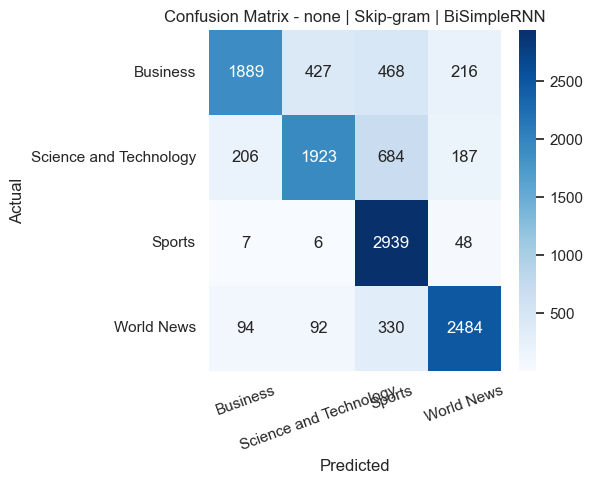

Epoch 1/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.8276 - loss: 0.4579 - val_accuracy: 0.9029 - val_loss: 0.2817
Epoch 2/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - accuracy: 0.9112 - loss: 0.2588 - val_accuracy: 0.9104 - val_loss: 0.2498
Epoch 3/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - accuracy: 0.9253 - loss: 0.2178 - val_accuracy: 0.9176 - val_loss: 0.2294
Epoch 4/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - accuracy: 0.9347 - loss: 0.1893 - val_accuracy: 0.9178 - val_loss: 0.2298
Epoch 5/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - accuracy: 0.9419 - loss: 0.1663 - val_accuracy: 0.9229 - val_loss: 0.2285
Epoch 6/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - accuracy: 0.9500 - loss: 0.1457 - val_accuracy: 0.9253 - val_loss: 0.2225
Epoch 7/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - accuracy: 0.9558 - loss: 0.1307 - val_accuracy: 0.9254 - val_loss: 0.2240
Epoch 8/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - accuracy: 0.9602 -

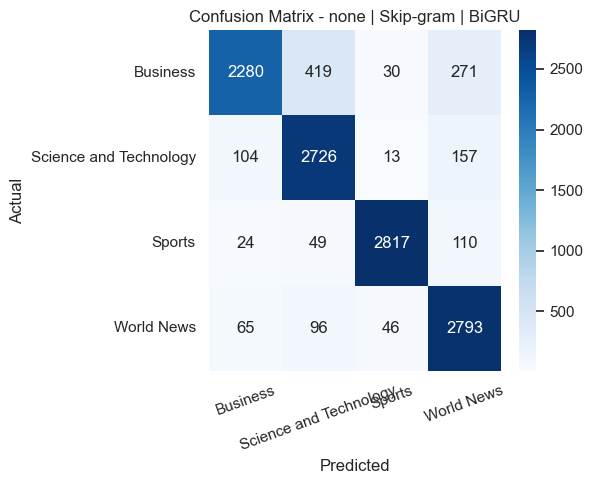

Epoch 1/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - accuracy: 0.8647 - loss: 0.3881 - val_accuracy: 0.8977 - val_loss: 0.2922
Epoch 2/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - accuracy: 0.9040 - loss: 0.2760 - val_accuracy: 0.9132 - val_loss: 0.2473
Epoch 3/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - accuracy: 0.9200 - loss: 0.2328 - val_accuracy: 0.9206 - val_loss: 0.2280
Epoch 4/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - accuracy: 0.9293 - loss: 0.2031 - val_accuracy: 0.9198 - val_loss: 0.2328
Epoch 5/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - accuracy: 0.9376 - loss: 0.1800 - val_accuracy: 0.9273 - val_loss: 0.2134
Epoch 6/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - accuracy: 0.9440 - loss: 0.1604 - val_accuracy: 0.9287 - val_loss: 0.2163
Epoch 7/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - accuracy: 0.9509 - loss: 0.1418 - val_accuracy: 0.9322 - val_loss: 0.2012
Epoch 8/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - accuracy: 0.9558 -

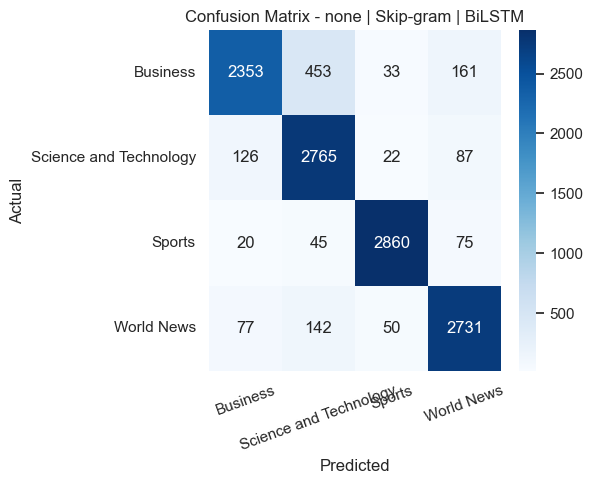


Skip-gram experiments for preprocessing: extreme
Epoch 1/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7068 - loss: 0.7499 - val_accuracy: 0.6985 - val_loss: 0.8128
Epoch 2/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7333 - loss: 0.6725 - val_accuracy: 0.7535 - val_loss: 0.6049
Epoch 3/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4289 - loss: 1.2042 - val_accuracy: 0.4016 - val_loss: 1.2504
Epoch 4/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.3923 - loss: 1.2480 - val_accuracy: 0.4016 - val_loss: 1.2498
SimpleRNN cfg: {'batch_size': 64, 'dropout_rate': 0.4, 'epochs': 50, 'lr': 0.001, 'units': 64} -> val_macro_f1=0.5604
Epoch 1/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7595 - loss: 0.6400 - val_accuracy: 0.6858 - val_loss: 0.7148
Epoch 2/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6567 - loss: 0.9129 - val_accuracy: 0.7099 - val_loss: 0.7984
SimpleRNN cfg: {'batch_size': 64, 'dropout_rate': 0.

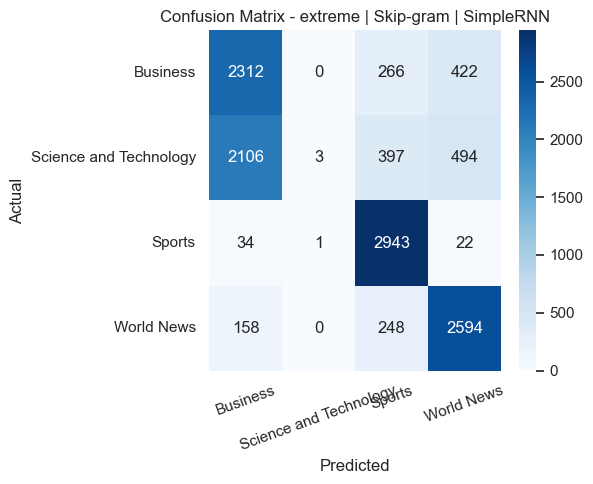

Epoch 1/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.7793 - loss: 0.5070 - val_accuracy: 0.9022 - val_loss: 0.2985
Epoch 2/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - accuracy: 0.9164 - loss: 0.2611 - val_accuracy: 0.9168 - val_loss: 0.2461
Epoch 3/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.9254 - loss: 0.2268 - val_accuracy: 0.9244 - val_loss: 0.2186
Epoch 4/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - accuracy: 0.9322 - loss: 0.2062 - val_accuracy: 0.9285 - val_loss: 0.2066
Epoch 5/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.9378 - loss: 0.1889 - val_accuracy: 0.9325 - val_loss: 0.1997
Epoch 6/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.9420 - loss: 0.1744 - val_accuracy: 0.9361 - val_loss: 0.1915
Epoch 7/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - accuracy: 0.9468 - loss: 0.1606 - val_accuracy: 0.9378 - val_loss: 0.1894
Epoch 8/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - accuracy: 0.9503 -

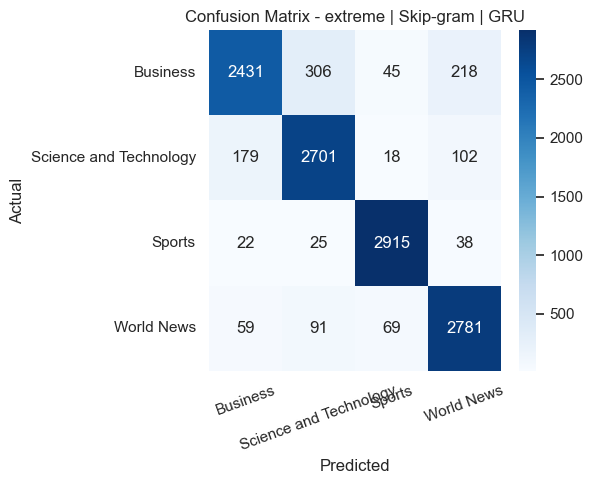

Epoch 1/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.8548 - loss: 0.4042 - val_accuracy: 0.9042 - val_loss: 0.3104
Epoch 2/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.9150 - loss: 0.2814 - val_accuracy: 0.9151 - val_loss: 0.2756
Epoch 3/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.9212 - loss: 0.2516 - val_accuracy: 0.9181 - val_loss: 0.2625
Epoch 4/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.9277 - loss: 0.2302 - val_accuracy: 0.9225 - val_loss: 0.2490
Epoch 5/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.9317 - loss: 0.2142 - val_accuracy: 0.9292 - val_loss: 0.2295
Epoch 6/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.9350 - loss: 0.2001 - val_accuracy: 0.9328 - val_loss: 0.2185
Epoch 7/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.9394 - loss: 0.1886 - val_accuracy: 0.9340 - val_loss: 0.2087
Epoch 8/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.9426 -

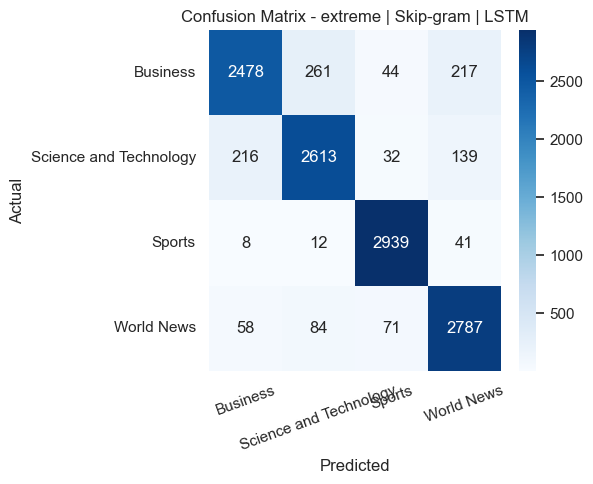

Epoch 1/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8790 - loss: 0.3651 - val_accuracy: 0.8991 - val_loss: 0.3135
Epoch 2/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9047 - loss: 0.3040 - val_accuracy: 0.9005 - val_loss: 0.3069
Epoch 3/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9070 - loss: 0.2926 - val_accuracy: 0.8969 - val_loss: 0.3220
Epoch 4/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9108 - loss: 0.2799 - val_accuracy: 0.9013 - val_loss: 0.3079
BiSimpleRNN cfg: {'batch_size': 64, 'dropout_rate': 0.4, 'epochs': 50, 'lr': 0.001, 'units': 64} -> val_macro_f1=0.8554
Epoch 1/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.8816 - loss: 0.3577 - val_accuracy: 0.9009 - val_loss: 0.3070
Epoch 2/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.9050 - loss: 0.2998 - val_accuracy: 0.9040 - val_loss: 0.2981
Epoch 3/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.9076 - loss: 0.2884 - val_accura

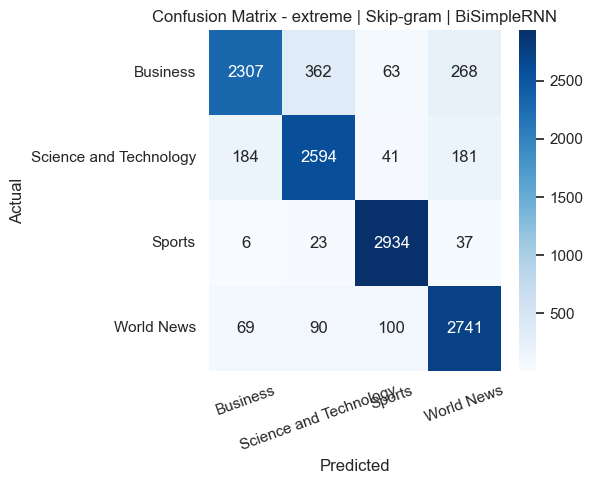

Epoch 1/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.8964 - loss: 0.3060 - val_accuracy: 0.9165 - val_loss: 0.2475
Epoch 2/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - accuracy: 0.9238 - loss: 0.2295 - val_accuracy: 0.9228 - val_loss: 0.2275
Epoch 3/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - accuracy: 0.9308 - loss: 0.2071 - val_accuracy: 0.9276 - val_loss: 0.2075
Epoch 4/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - accuracy: 0.9364 - loss: 0.1886 - val_accuracy: 0.9313 - val_loss: 0.1971
Epoch 5/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - accuracy: 0.9425 - loss: 0.1703 - val_accuracy: 0.9343 - val_loss: 0.1906
Epoch 6/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - accuracy: 0.9480 - loss: 0.1531 - val_accuracy: 0.9370 - val_loss: 0.1845
Epoch 7/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - accuracy: 0.9527 - loss: 0.1389 - val_accuracy: 0.9371 - val_loss: 0.1876
Epoch 8/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - accuracy: 0.9574 -

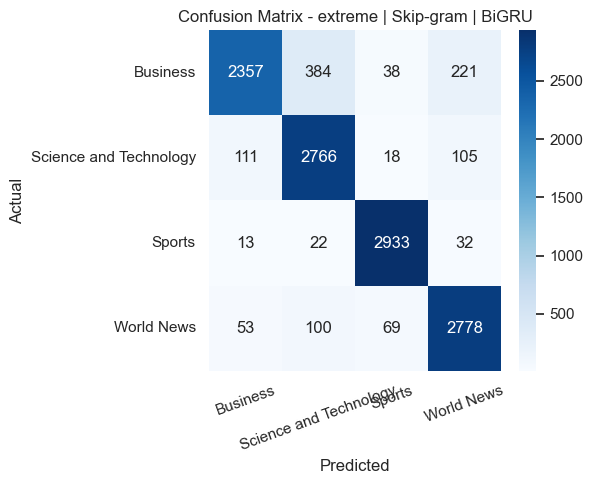

Epoch 1/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - accuracy: 0.9033 - loss: 0.2894 - val_accuracy: 0.9161 - val_loss: 0.2478
Epoch 2/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.9230 - loss: 0.2294 - val_accuracy: 0.9222 - val_loss: 0.2266
Epoch 3/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - accuracy: 0.9305 - loss: 0.2044 - val_accuracy: 0.9335 - val_loss: 0.1957
Epoch 4/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - accuracy: 0.9377 - loss: 0.1843 - val_accuracy: 0.9380 - val_loss: 0.1898
Epoch 5/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.9431 - loss: 0.1664 - val_accuracy: 0.9387 - val_loss: 0.1881
Epoch 6/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.9490 - loss: 0.1507 - val_accuracy: 0.9402 - val_loss: 0.1831
Epoch 7/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - accuracy: 0.9529 - loss: 0.1372 - val_accuracy: 0.9414 - val_loss: 0.1797
Epoch 8/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - accuracy: 0.9569 -

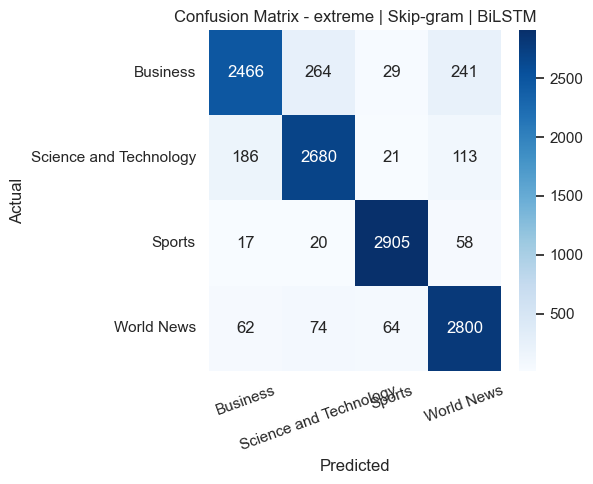


Skip-gram experiments for preprocessing: optimum
Epoch 1/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7333 - loss: 0.7326 - val_accuracy: 0.6918 - val_loss: 0.8651
Epoch 2/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6893 - loss: 0.9275 - val_accuracy: 0.6875 - val_loss: 0.9267
Epoch 3/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6918 - loss: 0.9194 - val_accuracy: 0.6878 - val_loss: 0.9244
SimpleRNN cfg: {'batch_size': 64, 'dropout_rate': 0.4, 'epochs': 50, 'lr': 0.001, 'units': 64} -> val_macro_f1=0.4013
Epoch 1/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6578 - loss: 0.7920 - val_accuracy: 0.7686 - val_loss: 0.5246
Epoch 2/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.5358 - loss: 1.0295 - val_accuracy: 0.4017 - val_loss: 1.2544
Epoch 3/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.3893 - loss: 1.2507 - val_accuracy: 0.4017 - val_loss: 1.2543
SimpleRNN cfg: {'batch_size': 64, 'dropout_rate': 0.

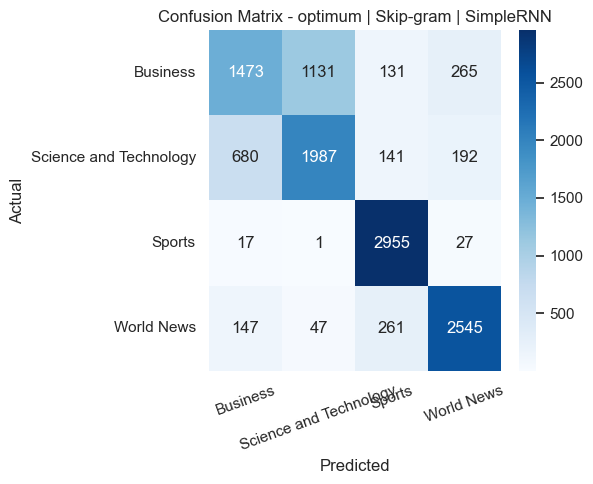

Epoch 1/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.7891 - loss: 0.5002 - val_accuracy: 0.9158 - val_loss: 0.2549
Epoch 2/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - accuracy: 0.9216 - loss: 0.2449 - val_accuracy: 0.9254 - val_loss: 0.2249
Epoch 3/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - accuracy: 0.9291 - loss: 0.2181 - val_accuracy: 0.9292 - val_loss: 0.2127
Epoch 4/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - accuracy: 0.9352 - loss: 0.1983 - val_accuracy: 0.9339 - val_loss: 0.1982
Epoch 5/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - accuracy: 0.9403 - loss: 0.1802 - val_accuracy: 0.9370 - val_loss: 0.1910
Epoch 6/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - accuracy: 0.9447 - loss: 0.1654 - val_accuracy: 0.9382 - val_loss: 0.1883
Epoch 7/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - accuracy: 0.9486 - loss: 0.1524 - val_accuracy: 0.9328 - val_loss: 0.2060
Epoch 8/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - accuracy: 0.9530 -

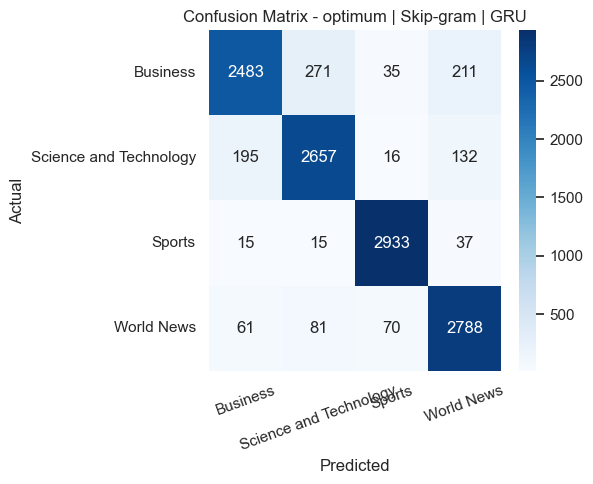

Epoch 1/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.8390 - loss: 0.4266 - val_accuracy: 0.8795 - val_loss: 0.3568
Epoch 2/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.9087 - loss: 0.2902 - val_accuracy: 0.9200 - val_loss: 0.2500
Epoch 3/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.9212 - loss: 0.2487 - val_accuracy: 0.9190 - val_loss: 0.2519
Epoch 4/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.9259 - loss: 0.2260 - val_accuracy: 0.9275 - val_loss: 0.2232
Epoch 5/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.9306 - loss: 0.2103 - val_accuracy: 0.9314 - val_loss: 0.2159
Epoch 6/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.9360 - loss: 0.1925 - val_accuracy: 0.9337 - val_loss: 0.2082
Epoch 7/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.9397 - loss: 0.1823 - val_accuracy: 0.9354 - val_loss: 0.2005
Epoch 8/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.9433 -

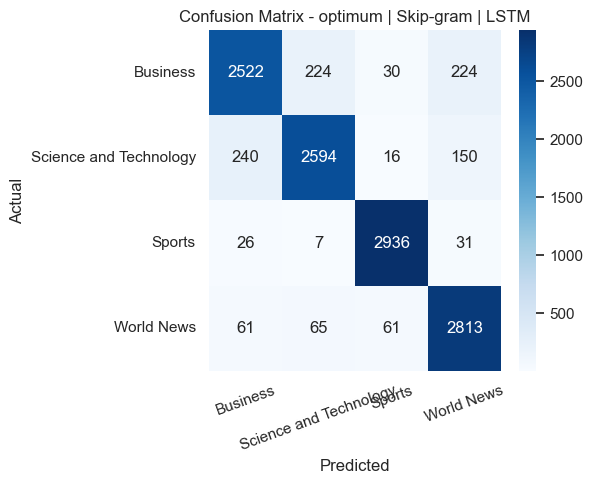

Epoch 1/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8803 - loss: 0.3658 - val_accuracy: 0.9048 - val_loss: 0.2905
Epoch 2/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9073 - loss: 0.2971 - val_accuracy: 0.9072 - val_loss: 0.2832
Epoch 3/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9101 - loss: 0.2884 - val_accuracy: 0.9078 - val_loss: 0.2860
Epoch 4/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9129 - loss: 0.2750 - val_accuracy: 0.9090 - val_loss: 0.2719
Epoch 5/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9121 - loss: 0.2734 - val_accuracy: 0.9054 - val_loss: 0.2816
Epoch 6/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9151 - loss: 0.2643 - val_accuracy: 0.9126 - val_loss: 0.2596
Epoch 7/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9145 - loss: 0.2646 - val_accuracy: 0.9120 - val_loss: 0.2624
Epoch 8/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9181 - loss: 0.2555 - 

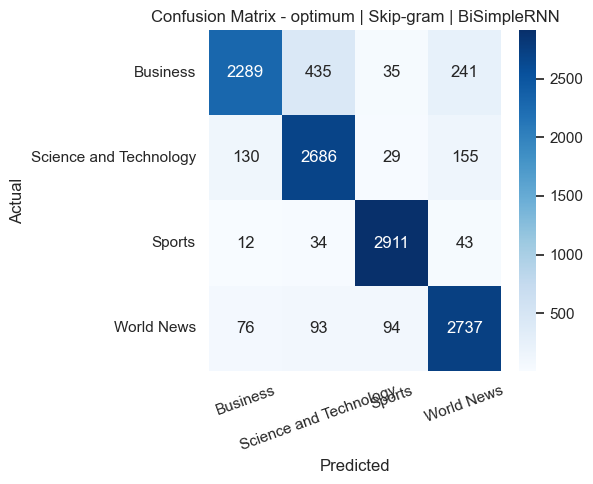

Epoch 1/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 21s 16ms/step - accuracy: 0.8994 - loss: 0.2969 - val_accuracy: 0.9224 - val_loss: 0.2317
Epoch 2/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - accuracy: 0.9257 - loss: 0.2219 - val_accuracy: 0.9271 - val_loss: 0.2107
Epoch 3/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - accuracy: 0.9320 - loss: 0.2012 - val_accuracy: 0.9332 - val_loss: 0.1924
Epoch 4/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - accuracy: 0.9378 - loss: 0.1835 - val_accuracy: 0.9350 - val_loss: 0.1846
Epoch 5/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - accuracy: 0.9436 - loss: 0.1671 - val_accuracy: 0.9361 - val_loss: 0.1820
Epoch 6/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - accuracy: 0.9482 - loss: 0.1521 - val_accuracy: 0.9439 - val_loss: 0.1656
Epoch 7/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - accuracy: 0.9528 - loss: 0.1377 - val_accuracy: 0.9466 - val_loss: 0.1625
Epoch 8/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - accuracy: 0.9583 -

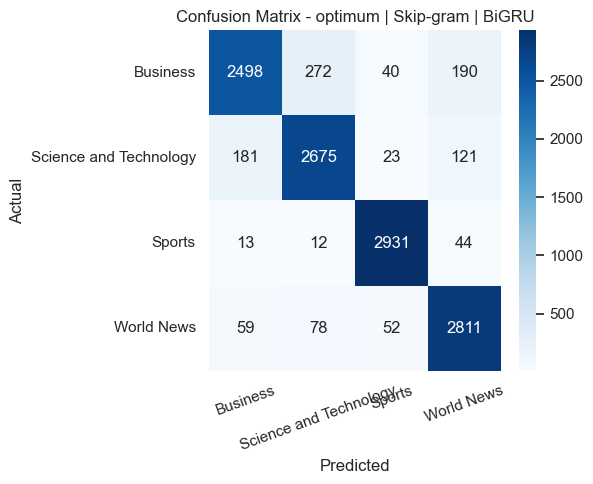

Epoch 1/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - accuracy: 0.9028 - loss: 0.2881 - val_accuracy: 0.9177 - val_loss: 0.2359
Epoch 2/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.9239 - loss: 0.2244 - val_accuracy: 0.9260 - val_loss: 0.2157
Epoch 3/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.9323 - loss: 0.2016 - val_accuracy: 0.9338 - val_loss: 0.1975
Epoch 4/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.9380 - loss: 0.1813 - val_accuracy: 0.9395 - val_loss: 0.1798
Epoch 5/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.9440 - loss: 0.1649 - val_accuracy: 0.9408 - val_loss: 0.1723
Epoch 6/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.9502 - loss: 0.1494 - val_accuracy: 0.9430 - val_loss: 0.1678
Epoch 7/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.9550 - loss: 0.1345 - val_accuracy: 0.9439 - val_loss: 0.1692
Epoch 8/50
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - accuracy: 0.9591 -

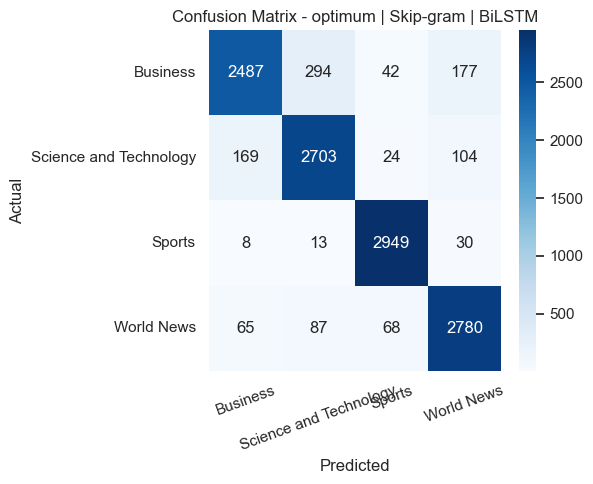

In [11]:
MAX_WORDS = 30000
MAX_LEN = 60
EMBED_DIM = 100

def build_embedding_matrix(word_index, w2v, max_words=MAX_WORDS, embed_dim=EMBED_DIM):
    vocab_size = min(max_words, len(word_index) + 1)
    emb_matrix = np.random.normal(scale=0.6, size=(vocab_size, embed_dim))
    emb_matrix[0] = np.zeros(embed_dim)
    for word, idx in word_index.items():
        if idx >= vocab_size:
            continue
        if word in w2v.wv:
            emb_matrix[idx] = w2v.wv[word]
    return emb_matrix

def tokenize_pad(X_train_text, X_val_text, X_test_text):
    tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
    tokenizer.fit_on_texts(X_train_text)

    X_train_seq = tokenizer.texts_to_sequences(X_train_text)
    X_val_seq = tokenizer.texts_to_sequences(X_val_text)
    X_test_seq = tokenizer.texts_to_sequences(X_test_text)

    X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
    X_val_pad = pad_sequences(X_val_seq, maxlen=MAX_LEN, padding='post', truncating='post')
    X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')
    return tokenizer, X_train_pad, X_val_pad, X_test_pad

def build_seq_model(model_type, vocab_size, emb_matrix, units=64, dropout_rate=0.5, lr=1e-3):
    model = Sequential()
    model.add(Embedding(
        input_dim=vocab_size,
        output_dim=emb_matrix.shape[1],
        weights=[emb_matrix],
        trainable=False
    ))

    if model_type == 'SimpleRNN':
        model.add(SimpleRNN(units))
    elif model_type == 'GRU':
        model.add(GRU(units))
    elif model_type == 'LSTM':
        model.add(LSTM(units))
    elif model_type == 'BiSimpleRNN':
        model.add(Bidirectional(SimpleRNN(units)))
    elif model_type == 'BiGRU':
        model.add(Bidirectional(GRU(units)))
    elif model_type == 'BiLSTM':
        model.add(Bidirectional(LSTM(units)))
    else:
        raise ValueError('Unknown model type')

    model.add(Dropout(dropout_rate))
    model.add(Dense(num_classes, activation='softmax'))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

seq_model_names = ['SimpleRNN', 'GRU', 'LSTM', 'BiSimpleRNN', 'BiGRU', 'BiLSTM']
seq_grid = {
    'units': [64, 96],
    'dropout_rate': [0.4, 0.5],
    'lr': [1e-3],
    'batch_size': [64],
    'epochs': [50]
}

for prep_name, prep_fn in PREPROCESSORS.items():
    print('\n' + '=' * 95)
    print('Skip-gram experiments for preprocessing:', prep_name)

    X_train_text, X_val_text, X_test_text = get_preprocessed_splits(prep_fn)
    train_sent_tokens = [txt.split() for txt in X_train_text]

    w2v = Word2Vec(
        sentences=train_sent_tokens,
        vector_size=EMBED_DIM,
        window=5,
        min_count=2,
        sg=1,
        workers=4,
        epochs=50,
        seed=SEED
    )

    tokenizer, X_train_pad, X_val_pad, X_test_pad = tokenize_pad(X_train_text, X_val_text, X_test_text)
    vocab_size = min(MAX_WORDS, len(tokenizer.word_index) + 1)
    emb_matrix = build_embedding_matrix(tokenizer.word_index, w2v)

    for model_name in seq_model_names:
        best_f1 = -1
        best_model = None
        early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

        for cfg in ParameterGrid(seq_grid):
            model = build_seq_model(
                model_type=model_name,
                vocab_size=vocab_size,
                emb_matrix=emb_matrix,
                units=cfg['units'],
                dropout_rate=cfg['dropout_rate'],
                lr=cfg['lr']
            )

            model.fit(
                X_train_pad, y_train_oh,
                validation_data=(X_val_pad, y_val_oh),
                epochs=cfg['epochs'],
                batch_size=cfg['batch_size'],
                verbose=1,
                callbacks=[early_stop]
            )

            val_pred = np.argmax(model.predict(X_val_pad, verbose=0), axis=1)
            val_f1 = f1_score(y_val, val_pred, average='macro')
            add_tuning_log(prep_name, 'Skip-gram', model_name, cfg, val_f1)
            print(f'{model_name} cfg: {cfg} -> val_macro_f1={val_f1:.4f}')

            if val_f1 > best_f1:
                best_f1 = val_f1
                best_model = model

        test_pred = np.argmax(best_model.predict(X_test_pad, verbose=0), axis=1)
        evaluate_and_store(y_test, test_pred, prep_name, 'Skip-gram', model_name)

## 9) Tuning Logs + Final Comparison Tables/Plots

Tuning log rows: 196


,preprocessing,representation,model,config,val_macro_f1
192,optimum,Skip-gram,BiLSTM,"{'batch_size': 64, 'dropout_rate': 0.4, 'epoch...",0.920533
12,none,TF-IDF,DeepNN,"{'batch_size': 64, 'dense1': 256, 'dense2': 12...",0.919727
13,none,TF-IDF,DeepNN,"{'batch_size': 64, 'dense1': 256, 'dense2': 12...",0.919037
188,optimum,Skip-gram,BiGRU,"{'batch_size': 64, 'dropout_rate': 0.4, 'epoch...",0.917421
17,none,TF-IDF,DeepNN,"{'batch_size': 64, 'dense1': 384, 'dense2': 12...",0.917034
79,none,TF-IDF,DeepNN,"{'batch_size': 64, 'dense1': 256, 'dense2': 19...",0.916853
180,optimum,Skip-gram,LSTM,"{'batch_size': 64, 'dropout_rate': 0.4, 'epoch...",0.916762
77,none,TF-IDF,DeepNN,"{'batch_size': 64, 'dense1': 256, 'dense2': 12...",0.916697
76,none,TF-IDF,DeepNN,"{'batch_size': 64, 'dense1': 256, 'dense2': 12...",0.916216
117,optimum,TF-IDF,DeepNN,"{'batch_size': 64, 'dense1': 256, 'dense2': 12...",0.916029


,preprocessing,representation,model,accuracy,macro_f1
0,extreme,TF-IDF,DeepNN,0.910750,0.910279
1,extreme,TF-IDF,DeepNN,0.910583,0.910051
2,optimum,TF-IDF,DeepNN,0.910250,0.909791
3,optimum,Skip-gram,BiLSTM,0.909917,0.909322
4,optimum,Skip-gram,BiGRU,0.909583,0.909065
5,optimum,Skip-gram,LSTM,0.905417,0.904920
6,optimum,Skip-gram,GRU,0.905083,0.904539
7,extreme,Skip-gram,BiLSTM,0.904250,0.903763
8,extreme,Skip-gram,BiGRU,0.902833,0.901906
9,extreme,Skip-gram,GRU,0.902333,0.901676


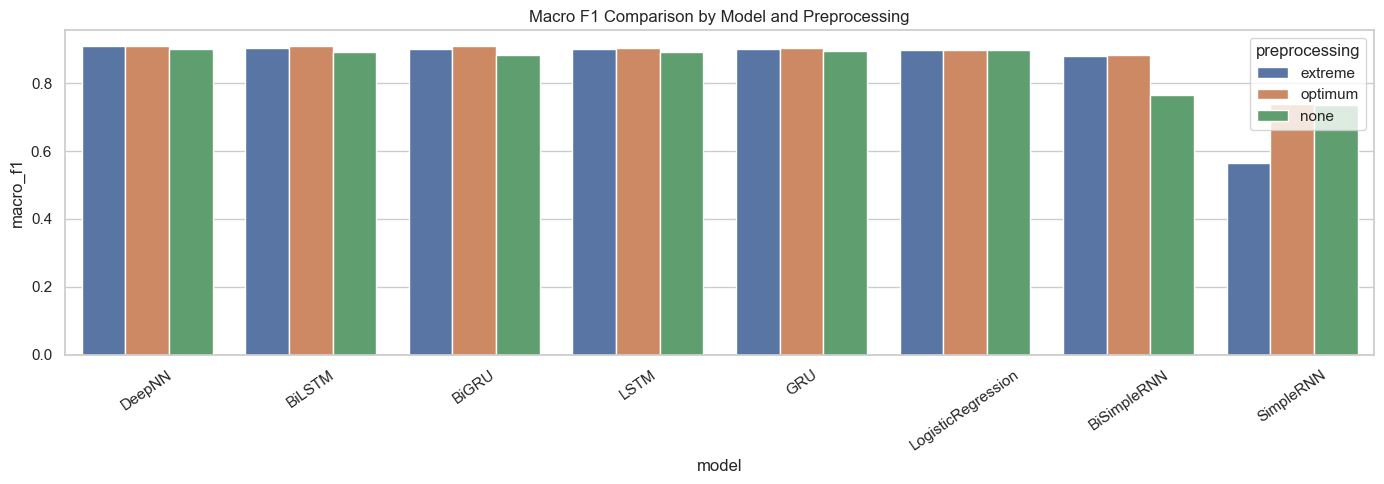

Best-performing experiment:
preprocessing      extreme
representation      TF-IDF
model               DeepNN
accuracy           0.91075
macro_f1          0.910279
Name: 0, dtype: object

Worst-performing experiment:
preprocessing       extreme
representation    Skip-gram
model             SimpleRNN
accuracy           0.654333
macro_f1           0.565658
Name: 29, dtype: object

Saved: final_results_table.csv, tuning_logs_table.csv


In [12]:
tuning_df = pd.DataFrame(tuning_logs)
results_df = pd.DataFrame(all_results)

print('Tuning log rows:', len(tuning_df))
display(tuning_df.sort_values('val_macro_f1', ascending=False).head(20))

results_df = results_df.sort_values(['macro_f1', 'accuracy'], ascending=False).reset_index(drop=True)
display(results_df)

plt.figure(figsize=(14, 5))
sns.barplot(data=results_df, x='model', y='macro_f1', hue='preprocessing')
plt.title('Macro F1 Comparison by Model and Preprocessing')
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()

best_exp = results_df.iloc[0]
worst_exp = results_df.iloc[-1]

print('Best-performing experiment:')
print(best_exp)

print('\nWorst-performing experiment:')
print(worst_exp)

results_df.to_csv('final_results_table.csv', index=False)
tuning_df.to_csv('tuning_logs_table.csv', index=False)
print('\nSaved: final_results_table.csv, tuning_logs_table.csv')

## 10) What to Include in IEEE Report (From this Notebook)

- Abstract: brief approach + strongest finding
- Introduction: task motivation + dataset overview
- Methodology:
  - EDA figures and observations
  - no/extreme/optimum preprocessing rationale
  - TF-IDF and Skip-gram representation details
  - model architecture details and tuning ranges
- Results:
  - per-model Accuracy, macro-F1, confusion matrices, classification reports
  - final comparison plot/table
- Conclusion:
  - best and worst combinations
  - limitations and future work
- References in IEEE style